# Combined LDPC Decoder Simulations
This notebook combines all simulation notebooks from the sims folder

## Setup: Import Required Libraries and Initialize Path

In [1]:
import os, sys

nb_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(nb_dir, '..'))
sys.path.insert(0, os.path.join(project_root, 'ldpc', 'src_python'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print('Using project root:', project_root)
print('First sys.path entry:', sys.path[0])

Using project root: /root/Research/RithvikDecoder/Decoder
First sys.path entry: /root/Research/RithvikDecoder/Decoder


In [2]:
import numpy as np
from scipy.sparse import csr_matrix, eye, hstack, save_npz, load_npz
import scipy.io
import matplotlib.pyplot as plt

In [3]:
from utils.LDPC_encode import LDPCEncode
from utils.awgn_channel import AWGNChannel
from utils.find_ber import findBER
from utils.res_cluster_picker import pick_max_avg_residual_cluster, pick_max_max_residual_cluster

In [4]:
from ldpc.bp_decoder import BpDecoder

## Load Data Files

In [5]:
H_mat_dat = scipy.io.loadmat('H.mat')
H = csr_matrix(H_mat_dat['H'])
m, n_code = H.shape
print(f"H matrix shape: {H.shape}")

H matrix shape: (162, 648)


In [6]:
# Prepare common parameters
n = 486  # length of message
n_frames = 100000  # reduced for faster combined simulation
max_iter = 30
snrs = [-3, -2, -1, 0, 1, 2]

# Create schedule for cluster-based decoding
arr = np.arange(m)
clusters = arr.reshape(6, -1)
print(f"Number of clusters: {len(clusters)}")

# Dictionary to store results
results = {}

Number of clusters: 6


## Generate Test Data

In [7]:
message = np.random.randint(0, 2, (n_frames, n))
encoded_codeword = LDPCEncode(message)
tx_codeword = 1 - 2 * encoded_codeword 

print("Message shape:", message.shape)
print("Encoded codeword shape:", encoded_codeword.shape)

Message shape: (100000, 486)
Encoded codeword shape: (100000, 648)


## Simulation 1: Flooding Schedule (test_flooding.ipynb)

In [8]:
print("\n" + "="*50)
print("Running Flooding Schedule Simulation")
print("="*50)

decoder_flooding = BpDecoder(H, max_iter=5)
bers_flooding = []

for snr in snrs:
    rx_llrs = AWGNChannel(tx_codeword, snr_db=snr)
    decoded_codewords = []
    
    for i in range(n_frames):
        llr = rx_llrs[i, :]
        decoded_codeword = decoder_flooding.decode(llr)
        decoded_codewords.append(decoded_codeword)
    
    decoded_codewords = np.array(decoded_codewords)
    decoded_message = decoded_codewords[:, :n]
    ber = findBER(message, decoded_message)
    bers_flooding.append(ber)
    print(f"BER at SNR {snr} dB: {ber:.6f}")

results['flooding'] = bers_flooding


Running Flooding Schedule Simulation
BER at SNR -3 dB: 0.158195
BER at SNR -2 dB: 0.129957
BER at SNR -1 dB: 0.101270
BER at SNR 0 dB: 0.070236
BER at SNR 1 dB: 0.029347
BER at SNR 2 dB: 0.001906


## Simulation 2: Random Schedule (test_random.ipynb)

In [9]:
print("\n" + "="*50)
print("Running Random Schedule Simulation")
print("="*50)

decoder_random = BpDecoder(H)
bers_random = []

for snr in snrs:
    rx_llrs = AWGNChannel(tx_codeword, snr_db=snr)
    decoded_codewords = []

    for i in range(n_frames):
        llr = rx_llrs[i, :]
        decoder_random.reset()
        decoder_random.initialise_log_domain_bp(llr)
        
        for iter in range(max_iter):
            # Random cluster selection
            x = np.random.randint(0, 6)
            cluster = clusters[x]
            llr = decoder_random.decode_cluster(cluster)
        
        decoded_codeword = (llr < 0).astype(int)
        decoded_codewords.append(decoded_codeword)
        
    decoded_codewords = np.array(decoded_codewords)
    decoded_message = decoded_codewords[:, :n]
    ber = findBER(message, decoded_message)
    bers_random.append(ber)
    print(f"BER at SNR {snr} dB: {ber:.6f}")

results['random'] = bers_random


Running Random Schedule Simulation
BER at SNR -3 dB: 0.158182
BER at SNR -2 dB: 0.129945
BER at SNR -1 dB: 0.101316
BER at SNR 0 dB: 0.070368
BER at SNR 1 dB: 0.030315
BER at SNR 2 dB: 0.002182


## Simulation 3: Residual-Based Picking (test_rbp.ipynb)

In [10]:
print("\n" + "="*50)
print("Running Residual-Based Picking Simulation")
print("="*50)

decoder_rbp = BpDecoder(H)
bers_rbp = []

for snr in snrs:
    rx_llrs = AWGNChannel(tx_codeword, snr_db=snr)
    decoded_codewords = []

    for i in range(n_frames):
        llr = rx_llrs[i, :]
        decoder_rbp.reset()
        decoder_rbp.initialise_log_domain_bp(llr)
        
        for iter in range(max_iter):
            residuals = decoder_rbp.get_residuals()
            cluster_idx, scheduled_cluster = pick_max_avg_residual_cluster(residuals, clusters)
            llr = decoder_rbp.decode_cluster(scheduled_cluster)

        decoded_codeword = (llr < 0).astype(int)
        decoded_codewords.append(decoded_codeword)
        
    decoded_codewords = np.array(decoded_codewords)
    decoded_message = decoded_codewords[:, :n]
    ber = findBER(message, decoded_message)
    bers_rbp.append(ber)
    print(f"BER at SNR {snr} dB: {ber:.6f}")

results['rbp'] = bers_rbp


Running Residual-Based Picking Simulation
BER at SNR -3 dB: 0.158273
BER at SNR -2 dB: 0.130018
BER at SNR -1 dB: 0.101270
BER at SNR 0 dB: 0.070236
BER at SNR 1 dB: 0.028561
BER at SNR 2 dB: 0.001531


## Simulation 4: Round-Robin Schedule (test_rr.ipynb)

In [ ]:
print("\n" + "="*50)
print("Running Round-Robin Schedule Simulation")
print("="*50)

decoder_rr = BpDecoder(H, schedule="cluster")
bers_rr = []

for snr in snrs:
    rx_llrs = AWGNChannel(tx_codeword, snr_db=snr)
    decoded_codewords = []

    for i in range(n_frames):
        llr = rx_llrs[i, :]
        decoder_rr.reset()
        decoder_rr.initialise_log_domain_bp(llr)
        
        for iter in range(5):  # Using reduced iterations for RR
            for cluster in clusters:
                llr = decoder_rr.decode_cluster(cluster)
        
        decoded_codeword = (llr < 0).astype(int)
        decoded_codewords.append(decoded_codeword)
        
    decoded_codewords = np.array(decoded_codewords)
    decoded_message = decoded_codewords[:, :n]
    ber = findBER(message, decoded_message)
    bers_rr.append(ber)
    print(f"BER at SNR {snr} dB: {ber:.6f}")

results['rr'] = bers_rr


Running Round-Robin Schedule Simulation
BER at SNR -3 dB: 0.158250
BER at SNR -2 dB: 0.130037
BER at SNR -1 dB: 0.101189
BER at SNR 0 dB: 0.070025
BER at SNR 1 dB: 0.024312


## Results: Compare and Visualize

In [ ]:
print("\n" + "="*50)
print("Results Summary")
print("="*50)

for method, bers in results.items():
    print(f"\n{method.upper()} Schedule:")
    for snr, ber in zip(snrs, bers):
        print(f"  SNR {snr:2d} dB: BER = {ber:.6f}")



Results Summary

FLOODING Schedule:
  SNR -3 dB: BER = 0.154177
  SNR -2 dB: BER = 0.131955
  SNR -1 dB: BER = 0.100741
  SNR  0 dB: BER = 0.069383
  SNR  1 dB: BER = 0.029198
  SNR  2 dB: BER = 0.001379
  SNR  3 dB: BER = 0.000000
  SNR  4 dB: BER = 0.000000

RANDOM Schedule:
  SNR -3 dB: BER = 0.158374
  SNR -2 dB: BER = 0.132737
  SNR -1 dB: BER = 0.102881
  SNR  0 dB: BER = 0.070412
  SNR  1 dB: BER = 0.032387
  SNR  2 dB: BER = 0.001440
  SNR  3 dB: BER = 0.000041
  SNR  4 dB: BER = 0.000000

RBP Schedule:
  SNR -3 dB: BER = 0.159856
  SNR -2 dB: BER = 0.131523
  SNR -1 dB: BER = 0.101276
  SNR  0 dB: BER = 0.067346
  SNR  1 dB: BER = 0.023724
  SNR  2 dB: BER = 0.001111
  SNR  3 dB: BER = 0.000000
  SNR  4 dB: BER = 0.000000

RR Schedule:
  SNR -3 dB: BER = 0.157407
  SNR -2 dB: BER = 0.128128
  SNR -1 dB: BER = 0.099259
  SNR  0 dB: BER = 0.066955
  SNR  1 dB: BER = 0.026420
  SNR  2 dB: BER = 0.000000
  SNR  3 dB: BER = 0.000000
  SNR  4 dB: BER = 0.000000


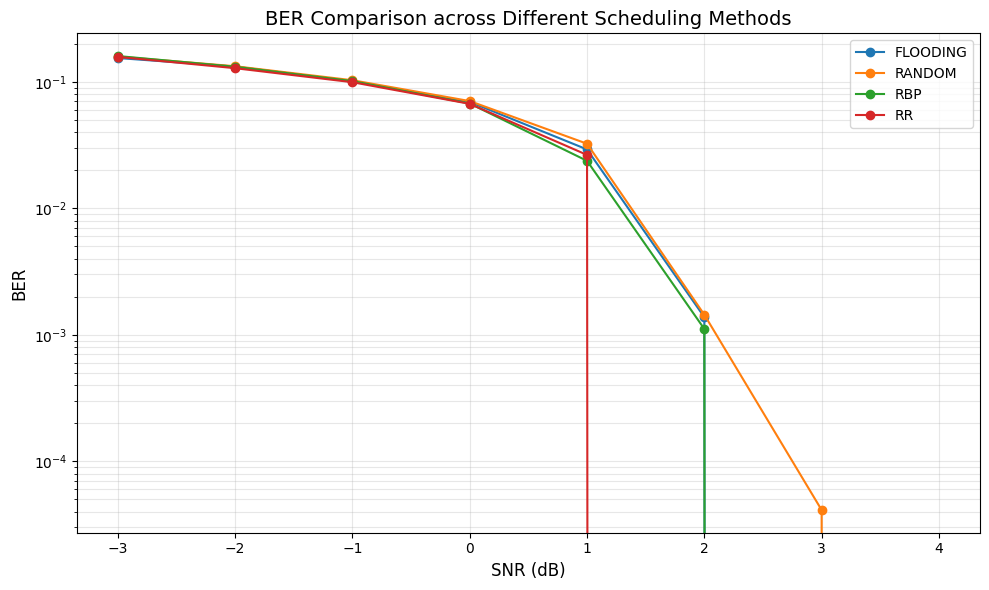


Comparison plot saved as 'combined_sims_comparison.png'


In [ ]:
plt.figure(figsize=(10, 6))

for method, bers in results.items():
    plt.semilogy(snrs, bers, marker='o', label=method.upper())

plt.xlabel('SNR (dB)', fontsize=12)
plt.ylabel('BER', fontsize=12)
plt.title('BER Comparison across Different Scheduling Methods', fontsize=14)
plt.grid(True, which='both', alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('combined_sims_comparison.png', dpi=150)
plt.show()

print("\nComparison plot saved as 'combined_sims_comparison.png'")